# 19. The `PipiKKRescattering` lineshape

**Objectives:** evaluate the standalone pi-pi <-> K-Kbar S-wave rescattering
amplitude, confirm it is exactly zero outside its 1.0-1.5 GeV window, compare the
`"paper"` and `"laura"` conventions, embed it in a one-resonance `DecayModel`, and
check a fit of its complex coefficient converges.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. `PipiKKRescattering` follows Eqs. (17)-(21) of
Phys. Rev. D 101, 012006 and is defined only in [mass_min, mass_max] (default
1.0-1.5 GeV); it is a spin-0 S-wave shape (`context.spin` must be 0).

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, Parameter, PipiKKRescattering, RealImag,
    Resonance, ResonanceContext, FitSession, generate_toy,
)

## 1. Zero outside the mass window

The shape is defined only between `mass_min` and `mass_max`; the constructor keeps
that window explicit even though Laura++ itself starts it at the K-Kbar threshold.

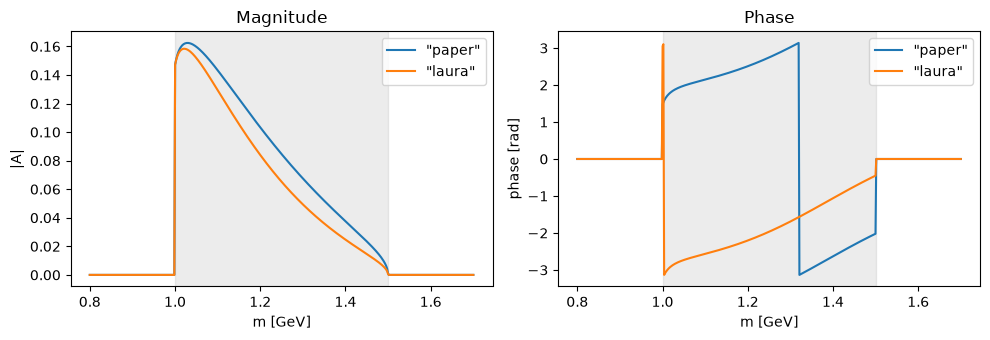

In [2]:
context = ResonanceContext(
    parent_mass=1.869, daughter_masses=(0.13957, 0.13957),
    bachelor_mass=0.13957, spin=0, pole_mass=1.2, pole_width=0.2,
)
mass_scan = jnp.linspace(0.8, 1.7, 500)
paper_amplitude = PipiKKRescattering(convention="paper")(mass_scan, context)
laura_amplitude = PipiKKRescattering(convention="laura")(mass_scan, context)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(mass_scan, jnp.abs(paper_amplitude), label='"paper"')
axes[0].plot(mass_scan, jnp.abs(laura_amplitude), label='"laura"')
axes[0].axvspan(1.0, 1.5, color="grey", alpha=0.15)
axes[0].set(xlabel="m [GeV]", ylabel="|A|", title="Magnitude")
axes[0].legend()
axes[1].plot(mass_scan, jnp.angle(paper_amplitude), label='"paper"')
axes[1].plot(mass_scan, jnp.angle(laura_amplitude), label='"laura"')
axes[1].axvspan(1.0, 1.5, color="grey", alpha=0.15)
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]", title="Phase")
axes[1].legend()
fig.tight_layout()
plt.show()

## 2. Confirm the window boundary explicitly

Outside `[mass_min, mass_max]` the amplitude must be exactly zero; inside it must be
finite and, generically, nonzero.

In [3]:
below = PipiKKRescattering()(jnp.asarray(0.95), context)
above = PipiKKRescattering()(jnp.asarray(1.55), context)
inside = PipiKKRescattering()(jnp.asarray(1.2), context)
print("below window:", below, " above window:", above, " inside window:", inside)
assert below == 0.0 and above == 0.0
assert jnp.isfinite(inside) and inside != 0.0
print("PipiKKRescattering is exactly zero outside [1.0, 1.5] GeV, as documented.")

below window: 0j  above window: 0j  inside window: (-0.08326148529283892+0.06114372580650817j)
PipiKKRescattering is exactly zero outside [1.0, 1.5] GeV, as documented.


## 3. A one-resonance Dalitz model

`PipiKKRescattering` plugs into `Resonance` for the `(0, 1)` pair (`pi- pi+`) of a
`D+ -> pi- pi+ pi+` toy channel, spin 0. The `mass`/`width` arguments of `Resonance`
are unused by this lineshape (it reads its own dataclass fields, not the context's
`pole_mass`/`pole_width`), so any placeholder values are fine.

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
def coeff(name, x0, y0):
    return RealImag(
        Parameter.coefficient(f"{name}.x", x0, owner=name, bounds=(-3.0, 3.0)),
        Parameter.coefficient(f"{name}.y", y0, owner=name, bounds=(-3.0, 3.0)),
    )
model = DecayModel(
    channel,
    components=[
        Resonance("f0KK", (0, 1), coeff("f0KK", 1.0, 0.0),
                  lineshape=PipiKKRescattering(convention="paper"),
                  mass=1.2, width=0.2, spin=0, normalize_component=False),
        NonResonant(coeff("NR", 0.30, -0.15), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=60,
)
truth = {p.name: p.value for p in model.parameters}
print("Parameters:", list(truth))

Parameters: ['f0KK.x', 'f0KK.y', 'NR.x', 'NR.y']


## 4. Generate a toy and fit the complex coefficient

In [5]:
data = generate_toy(
    model, 1500, parameters=truth, seed=19,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Generated {data.size} events")

session = FitSession(model, data)
start = {"f0KK.x": 0.7, "f0KK.y": 0.3, "NR.x": 0.2, "NR.y": -0.05}
result = session.fit(start, simplex=True, ncall=5000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before trusting this result."


Generated 1500 events


valid=True  NLL=2095.731506
parameter                           value            error
f0KK.x                           0.854181          4.81994
f0KK.y                           0.224335          4.38224
NR.x                             0.306245          2.07312
NR.y                           -0.0638742           1.1025


Fit fractions (physical)
component                    fraction [%]
f0KK                               75.768
NR                                155.495
sum                               231.264


## 5. Sanity check

In [6]:
fit_nll = float(session.objective({n: float(result.values[n]) for n in result.parameters}))
truth_nll = float(session.objective(truth))
print(f"NLL(fit)={fit_nll:.4f}, NLL(truth)={truth_nll:.4f}")
assert fit_nll <= truth_nll + 1e-4
print("Fit with a PipiKKRescattering component converges to an NLL at or below truth.")

NLL(fit)=2095.7315, NLL(truth)=2098.8029
Fit with a PipiKKRescattering component converges to an NLL at or below truth.


## Continue learning

See `docs/reviews/20260914_pipi_kk_rescattering.md` for the numeric reproduction of
`LauRescatteringRes::amplitude` behind the `"laura"` convention, and
[lineshapes](../../docs/lineshapes.md) more generally.

Return to [the course guide](TUTORIALS.md).